In [59]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
import torch.fft as fft
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import resnet18, ResNet18_Weights 
from torchvision.models import resnet34, ResNet34_Weights 
from torchvision.models import resnet50, ResNet50_Weights 
from torchvision.models import resnet101, ResNet101_Weights 

# -------------------------------
# 1. Configuration
# -------------------------------
IMAGENET_DIR = ""
SAVE_PATH = "zero/"
BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_BATCHES = 2000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("cpu")
SEED = 42

## Сохранненные спектры открыть

In [60]:
spectra_18 = np.load(f'{SAVE_PATH}resnet18.npz', allow_pickle=True)
spectra_34 = np.load(f'{SAVE_PATH}resnet34.npz', allow_pickle=True)
spectra_50 = np.load(f'{SAVE_PATH}resnet50.npz', allow_pickle=True)
spectra_101 = np.load(f'{SAVE_PATH}resnet101.npz', allow_pickle=True)

models_dict = {
    "ResNet_18": spectra_18,
    "ResNet_34": spectra_34,
    "ResNet_50": spectra_50,
    "ResNet_101": spectra_101
}
markers = {
    "ResNet_18": "s",
    "ResNet_34": "o",
    "ResNet_50": "<",
    "ResNet_101": "d"
}

## Функции

In [3]:
def ploting_image(feats, image):
    fig, axes = plt.subplots(1, 5, figsize=(30, 10))
    axes[0].imshow(np.mean(image[-1].numpy(), axis=0), cmap='gray')
    # print(image.shape)
    for i, (name, feat) in enumerate(feats.items()):
    
        feat = feat[-1].squeeze(0).mean(dim=0)
        axes[i+1].imshow(feat.cpu().numpy(), cmap='viridis')
        axes[i+1].set_title(f"Канал {i}")
        axes[i+1].axis('off')
    plt.show()

In [61]:
# -------------------------------
# 2. Reproducibility
# -------------------------------
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(SEED)

# -------------------------------
# 3. ImageNet DataLoader
# -------------------------------
def get_imagenet_val_loader(data_dir, batch_size, num_workers):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize,
    ])
    val_dataset = datasets.ImageFolder(root="imagenet", transform=val_transform)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                             shuffle=False, num_workers=num_workers, pin_memory=True)
    return val_loader

# -------------------------------
# 4. Spectral Analysis Functions
# -------------------------------
def compute_fft_power(feat):
    feat = feat.float()
    F2 = fft.fft2(feat, norm="ortho")
    F2_shift = fft.fftshift(F2, dim=(-2, -1))
    power = torch.abs(F2_shift) ** 2
    power_mean = power.mean(dim=(0, 1))  # [H, W]
    return power_mean.cpu()

def radial_average(power_2d):
    H, W = power_2d.shape
    cy, cx = H // 2, W // 2
    y = np.arange(H) - cy
    x = np.arange(W) - cx
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    R_int = R.astype(np.int32)

    r_max = R_int.max()
    radial_sum = np.zeros(r_max + 1, dtype=np.float64)
    radial_count = np.zeros(r_max + 1, dtype=np.int64)

    power_np = power_2d.numpy()
    for r in range(r_max + 1):
        mask = (R_int == r)
        radial_sum[r] = power_np[mask].sum()
        radial_count[r] = mask.sum()

    radial_mean = np.zeros_like(radial_sum)
    nonzero = radial_count > 0
    radial_mean[nonzero] = radial_sum[nonzero] / radial_count[nonzero]

    s = radial_mean.sum()
    if s > 0:
        radial_mean = radial_mean / s

    return radial_mean

# -------------------------------
# 5. Hooked Model
# -------------------------------
class HookedResNet(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.features = {}

        def hook_fn(name):
            def fn(module, input, output):
                self.features[name] = output.detach()
            return fn

        self.model.layer1.register_forward_hook(hook_fn("layer1"))
        self.model.layer2.register_forward_hook(hook_fn("layer2"))
        self.model.layer3.register_forward_hook(hook_fn("layer3"))
        self.model.layer4.register_forward_hook(hook_fn("layer4"))

    def forward(self, x):
        self.features = {}
        return self.model(x)

    def get_features(self):
        return self.features

# -------------------------------
# 6. Run Spectral Analysis
# -------------------------------
def collect_spectra(model, loader, device, max_batches, image_plot=None):
    model.eval()
    spectra = {}
    processed = 0

    with torch.no_grad():
        cnt = 0
        for images, _ in loader:
            cnt = cnt + 1
            if cnt%30==13: print(f'{cnt} ')
            images = images.to(device)
            _ = model(images)
                
            feats = model.get_features()
            
            if image_plot:
                ploting_image(feats, images)
            
            for name, feat in feats.items():
                spatial_mean = feat.mean(dim=(-2, -1), keepdim=True)  # [B, C, 1, 1]
                feat = feat - spatial_mean

                power_2d = compute_fft_power(feat)
                curve = radial_average(power_2d)
                spectra.setdefault(name, []).append(curve)

            processed += 1
            if processed >= max_batches:
                break

    mean_spectra = {}
    for name, curves in spectra.items():
        min_len = min(c.shape[0] for c in curves)
        aligned = np.stack([c[:min_len] for c in curves], axis=0)
        mean_curve = aligned.mean(axis=0)
        mean_spectra[name] = mean_curve
    return mean_spectra

# -------------------------------
# 8. Main Execution
# -------------------------------
def main():
    val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
    base_model = resnet18(weights=ResNet18_Weights.DEFAULT).to(DEVICE)
    model = HookedResNet(base_model).to(DEVICE)

    spectra = collect_spectra(model, val_loader, DEVICE, MAX_BATCHES)
    plot_spectra(spectra, save_path="resnet18_imagenet_spectra.png")

# main()

## Получение спектров

In [31]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_model_18 = resnet18(weights=ResNet18_Weights.DEFAULT).to(DEVICE)
model_18 = HookedResNet(base_model_18).to(DEVICE)

In [5]:
MAX_BATCHES = 1000
spectra_18 = collect_spectra(model_18, val_loader, DEVICE, MAX_BATCHES)

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


1 
2 
3 
4 
5 
6 
7 
8 
9 
10 
11 
12 
13 
14 
15 
16 
17 
18 
19 
20 
21 
22 
23 
24 
25 
26 
27 
28 
29 
30 
31 
32 
33 
34 
35 
36 
37 
38 
39 
40 
41 
42 
43 
44 
45 
46 
47 
48 
49 
50 
51 
52 
53 
54 
55 
56 
57 
58 
59 
60 
61 
62 
63 
64 
65 
66 
67 
68 
69 
70 
71 
72 
73 
74 
75 
76 
77 
78 
79 
80 
81 
82 
83 
84 
85 
86 
87 
88 
89 
90 
91 
92 
93 
94 
95 
96 
97 
98 
99 
100 
101 
102 
103 
104 
105 
106 
107 
108 
109 
110 
111 
112 
113 
114 
115 
116 
117 
118 
119 
120 
121 
122 
123 
124 
125 
126 
127 
128 
129 
130 
131 
132 
133 
134 
135 
136 
137 
138 
139 
140 
141 
142 
143 
144 
145 
146 
147 
148 
149 
150 
151 
152 
153 
154 
155 
156 
157 
158 
159 
160 
161 
162 
163 
164 
165 
166 
167 
168 
169 
170 
171 
172 
173 
174 
175 
176 
177 
178 
179 
180 
181 
182 
183 
184 
185 
186 
187 
188 
189 
190 
191 
192 
193 
194 
195 
196 
197 
198 
199 
200 
201 
202 
203 
204 
205 
206 
207 
208 
209 
210 
211 
212 
213 
214 
215 
216 
217 
218 
219 
220 
221 
222

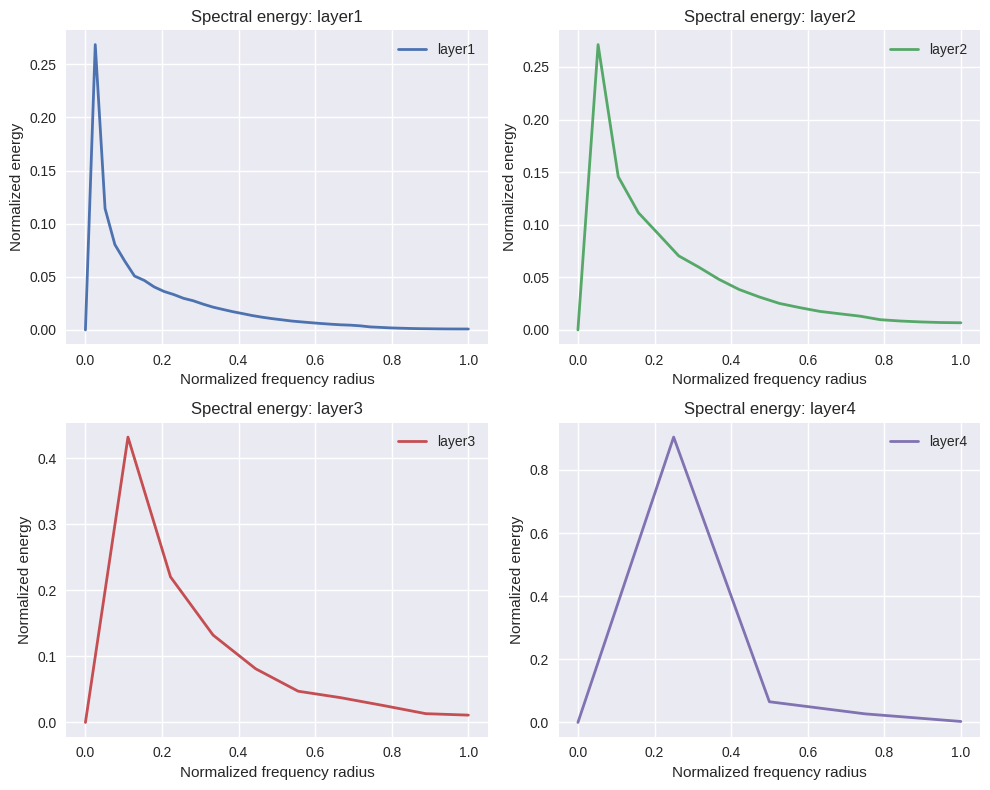

In [10]:
plot_spectra(spectra_18, save_path=f"{SAVE_PATH}resnet18_imagenet_spectra.png")
np.savez(f"{SAVE_PATH}resnet18.npz", **spectra_18)

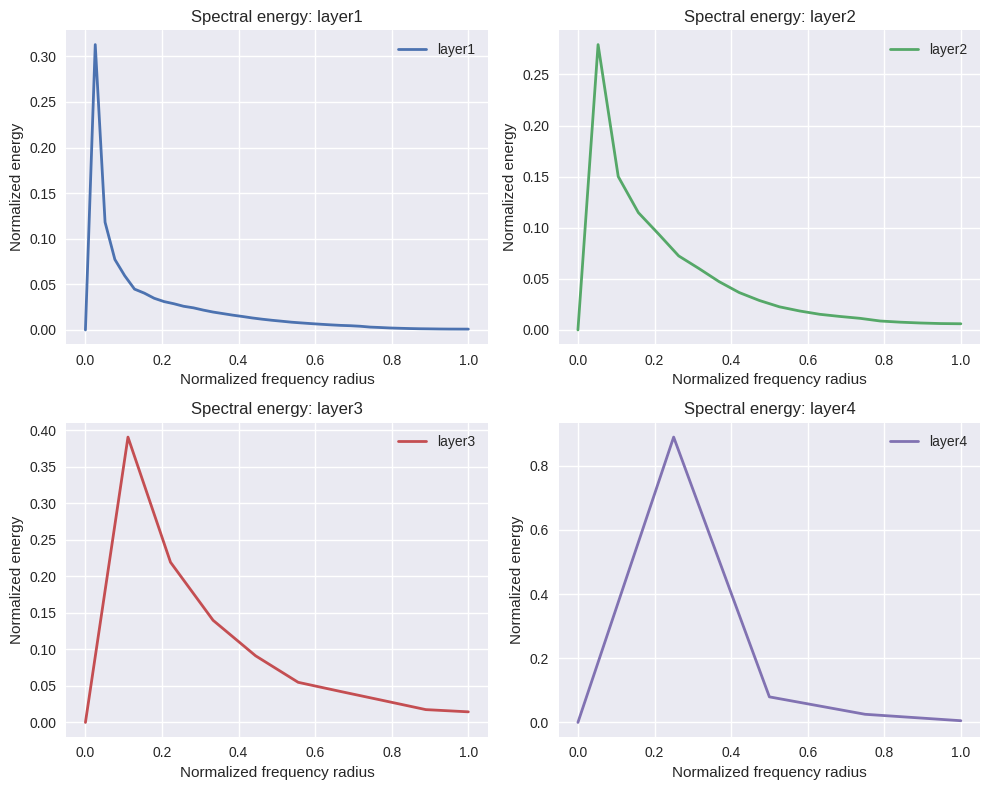

In [18]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_model_34 = resnet34(weights=ResNet34_Weights.DEFAULT).to(DEVICE)
model_34 = HookedResNet(base_model_34).to(DEVICE)

spectra_34 = collect_spectra(model_34, val_loader, DEVICE, MAX_BATCHES)
np.savez(f"{SAVE_PATH}resnet34.npz", **spectra_34)
plot_spectra(spectra_34, save_path=f"{SAVE_PATH}resnet34_imagenet_spectra.png")

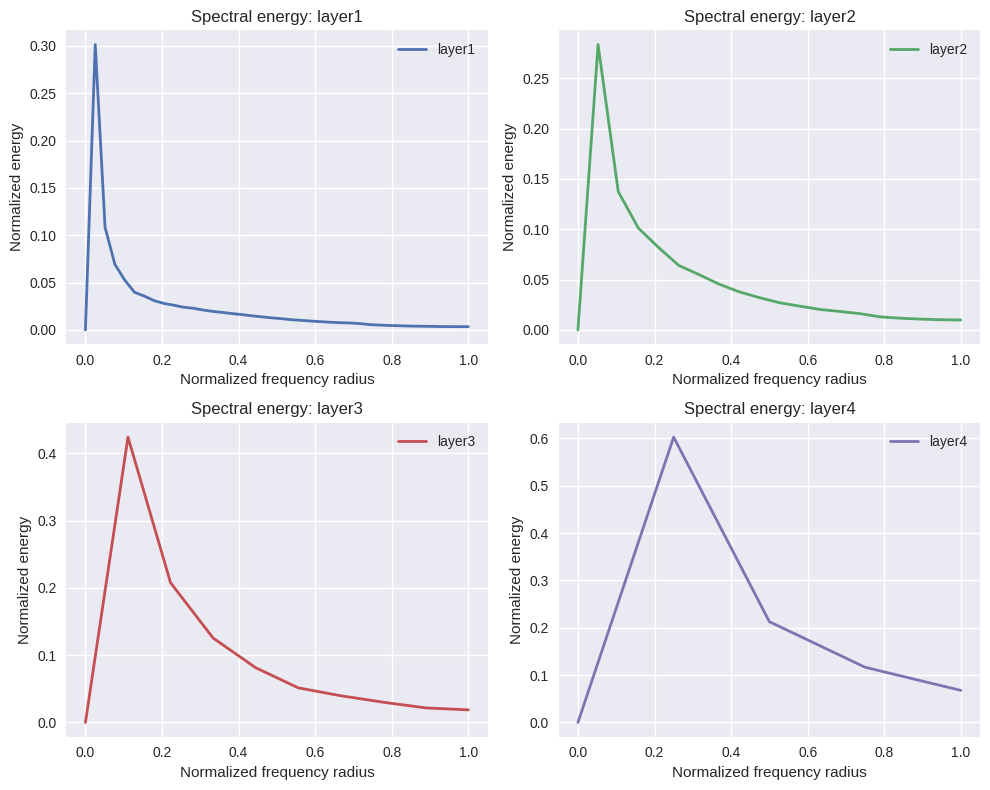

In [19]:

val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_model_50 = resnet50(weights=ResNet50_Weights.DEFAULT).to(DEVICE)
model_50 = HookedResNet(base_model_50).to(DEVICE)

spectra_50 = collect_spectra(model_50, val_loader, DEVICE, MAX_BATCHES)
np.savez(f"{SAVE_PATH}resnet50.npz", **spectra_50)
plot_spectra(spectra_50, save_path=f"{SAVE_PATH}resnet50_imagenet_spectra.png")


/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


13 
43 
73 
103 
133 
163 
193 
223 
253 
283 
313 


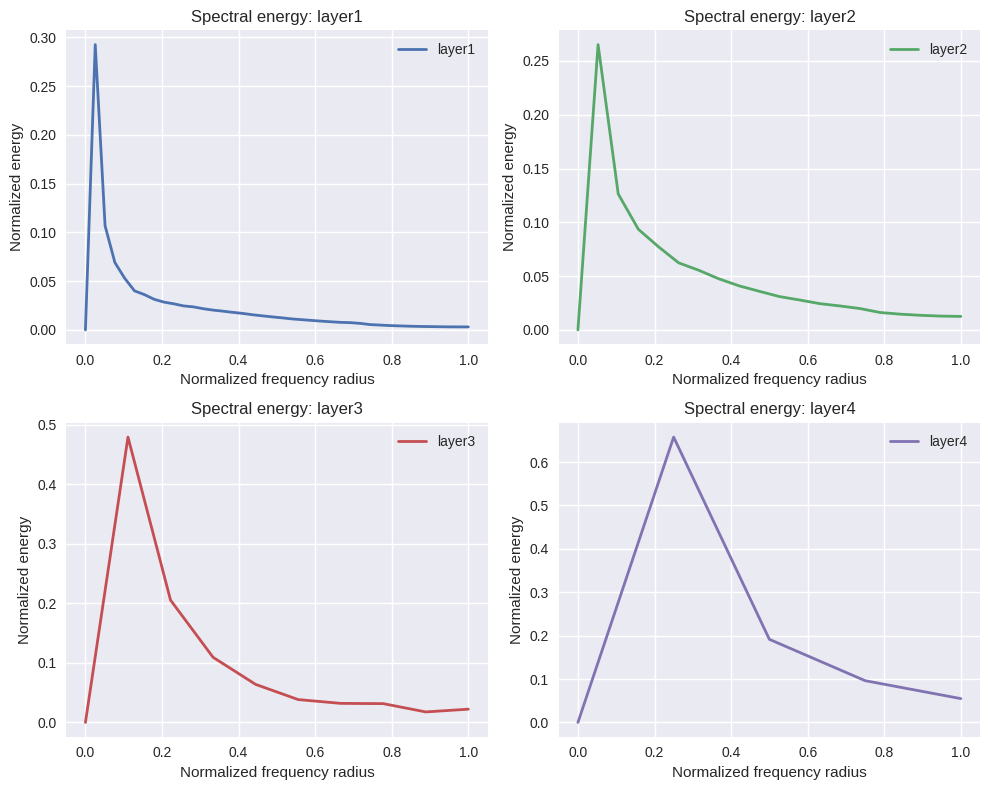

In [20]:

val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_model_101 = resnet101(weights=ResNet101_Weights.DEFAULT).to(DEVICE)
model_101 = HookedResNet(base_model_101).to(DEVICE)

spectra_101 = collect_spectra(model_101, val_loader, DEVICE, MAX_BATCHES)
np.savez(f"{SAVE_PATH}resnet101.npz", **spectra_101)

plot_spectra(spectra_101, save_path=f"{SAVE_PATH}resnet101_imagenet_spectra.png")

## Графики отрисовка

In [68]:
def plot_spectra(spectra_dict, save_path=None):
    plt.style.use("seaborn-v0_8")
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.ravel()
    blocks = ["layer1", "layer2", "layer3", "layer4"]

    for i, blk in enumerate(blocks):
        if blk in spectra_dict:
            curve = spectra_dict[blk]
            x = np.arange(len(curve)) / max(1, (len(curve) - 1))
            axs[i].plot(x, curve, label=blk, color=f"C{i}", linewidth=3)
            axs[i].set_title(f"Спектральная энергия: {blk}", fontsize=25, fontweight='bold', pad=20)
            axs[i].set_xlabel("Нормализованный частотный радиус", fontsize=25, labelpad=20)
            axs[i].set_ylabel("Нормализованная энергия", fontsize=25, labelpad=20)
            axs[i].grid(True)
            axs[i].legend(fontsize=20)

    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

def plot_spectra_compare(model_name, spectra, save_path=None):
    # Spatial resolutions of each layer (used to scale frequency axes)
    resolutions = {layer: len(curve) for layer, curve in spectra.items()}
    
    # Reference resolution (Layer1)
    ref_res = resolutions["layer1"]
    
    # Plotting
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))
    
    for i, (layer, curve) in enumerate(spectra.items()):
        curve = curve / max(curve)  # normalize energy
        L = len(curve)
        x = np.arange(L) / (L - 1)  # normalized frequency radius
        scale = resolutions[layer] / ref_res  # map to Layer1 frequency scale
        x_mapped = x * scale
        plt.plot(x_mapped, curve, label=layer, color=f"C{i}", linewidth=3)
    
    plt.title(f"Спектральная энергия слоев {model_name}", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \n приведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=25)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

def plot_spectra_compare_in_layer(models_dict, block, save_path=None):
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))
    
    for key, spectra in models_dict.items():
        resolutions = {layer: len(curve) for layer, curve in spectra.items()}
        ref_res = resolutions["layer1"]
        
        for i, (layer, curve) in enumerate(spectra.items()):
            if block=="начального": 
                if i>0: continue
            if block=="последнего": 
                if i!=3: continue
            if block=="среднего": 
                if i!=1: continue
            
            curve = curve / curve.max()  # normalize energy
            L = len(curve)
            x = np.arange(L) / (L - 1)  # normalized frequency radius
            scale = resolutions[layer] / ref_res  # map to Layer1 frequency scale
            x_mapped = x * scale
            plt.plot(x_mapped, curve, label=f'{key}-{layer}', color=f"C{i}", linewidth=2,marker = markers[key])
    
    plt.title(f"Спектральная энергия ResNet {block} слоя", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=25)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)

## На разных слоях как видут себя CNN

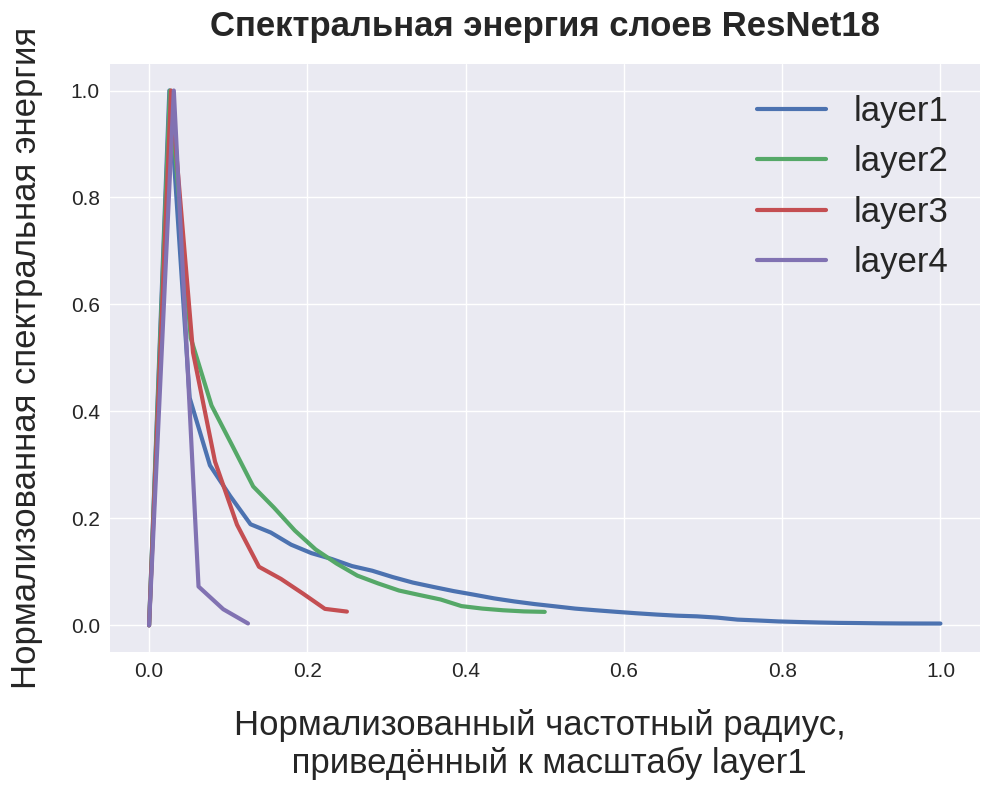

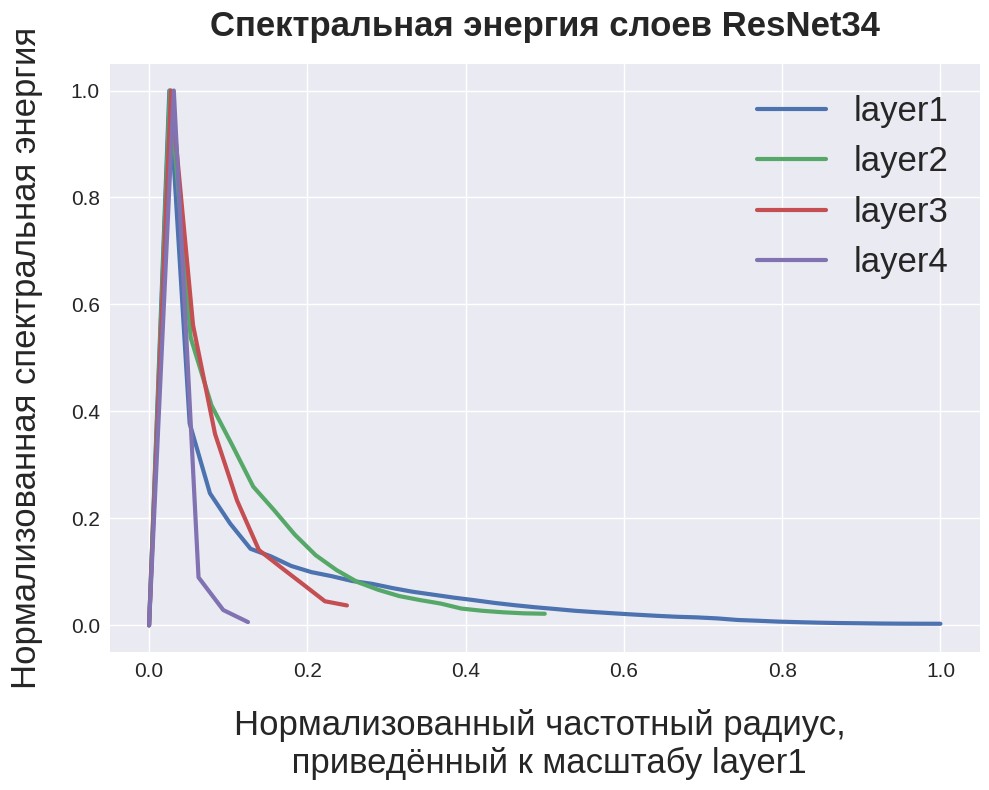

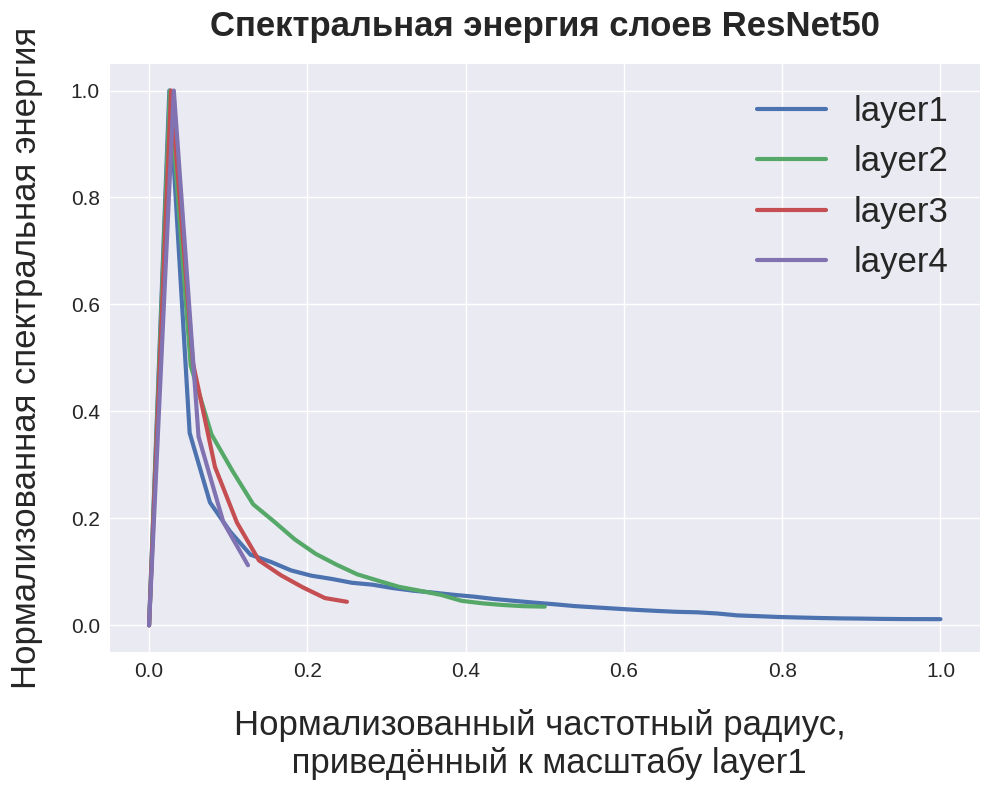

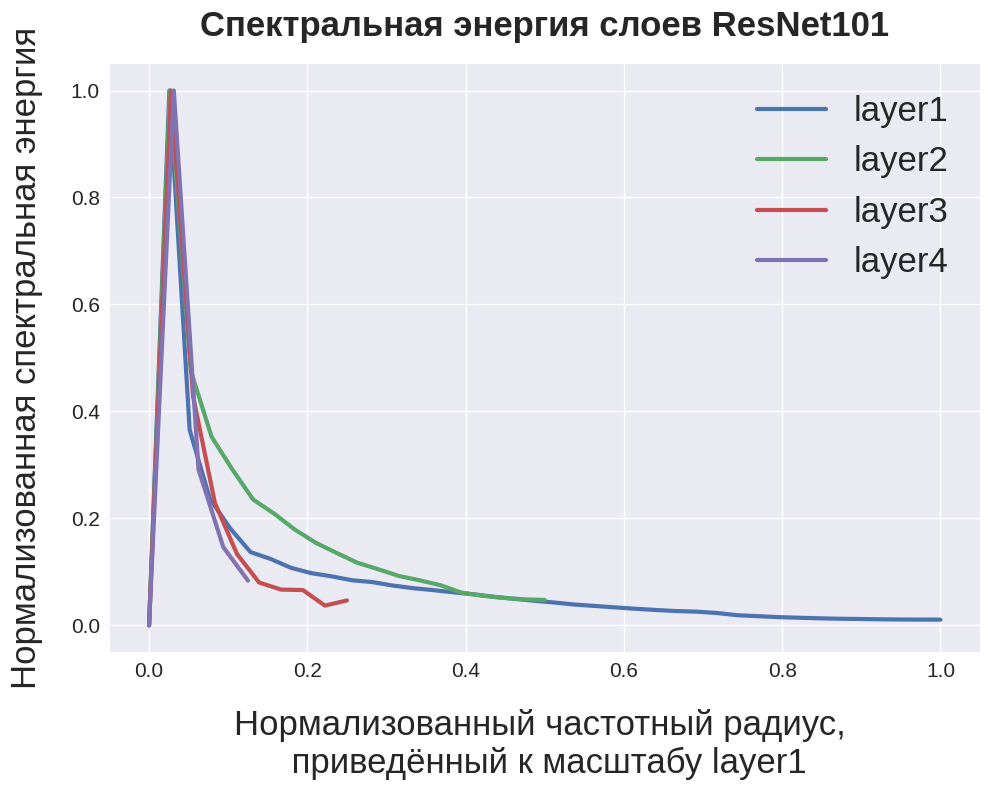

In [69]:
plot_spectra_compare("ResNet18",spectra_18, save_path=f"{SAVE_PATH}compare/ResNet18.png")
plot_spectra_compare("ResNet34",spectra_34, save_path=f"{SAVE_PATH}compare/ResNet34.png")
plot_spectra_compare("ResNet50",spectra_50, save_path=f"{SAVE_PATH}compare/ResNet50.png")
plot_spectra_compare("ResNet101",spectra_101, save_path=f"{SAVE_PATH}compare/ResNet101.png")

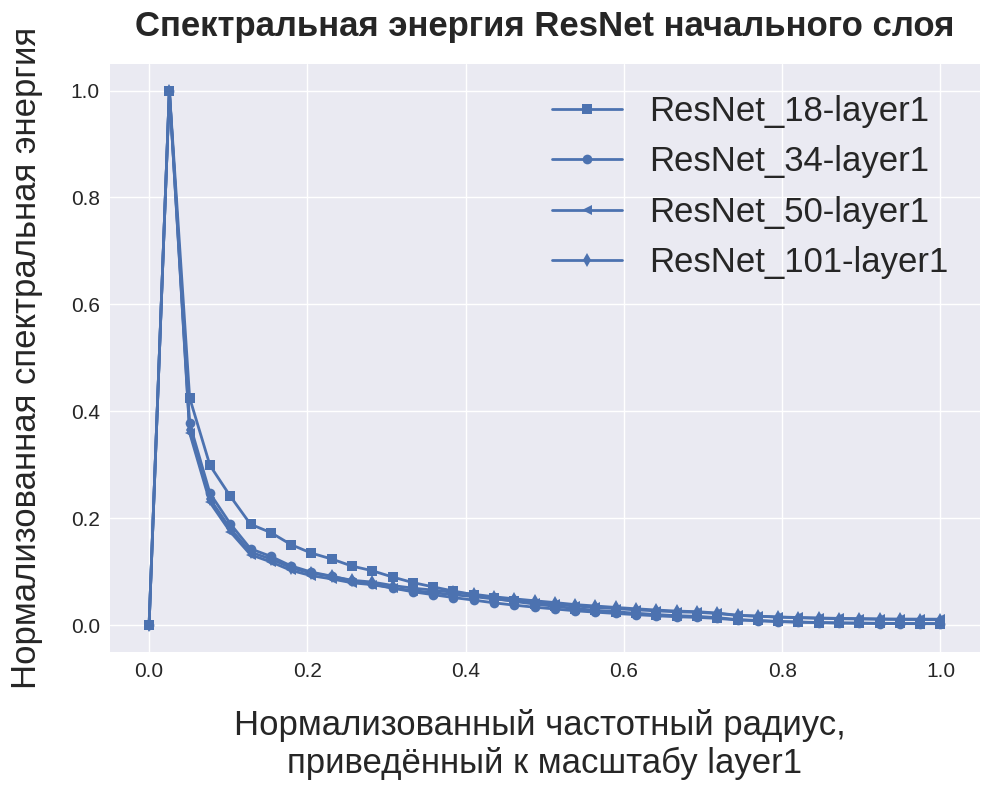

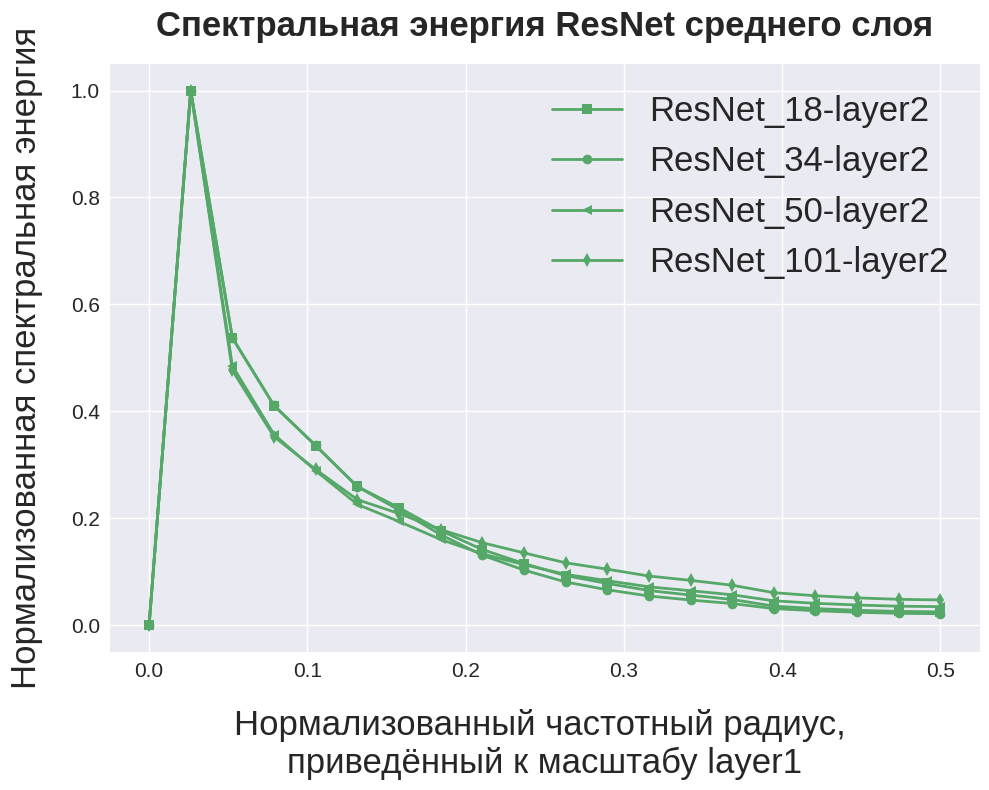

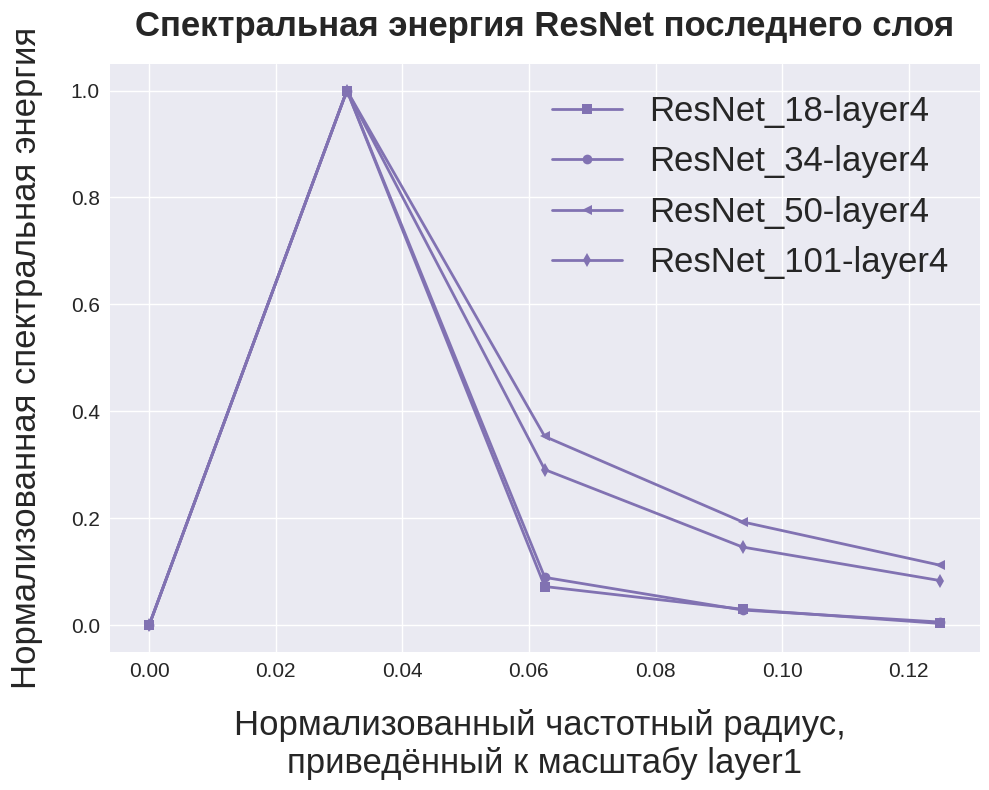

In [70]:
plot_spectra_compare_in_layer(models_dict, "начального", save_path=f"{SAVE_PATH}compare/resnet_block_0.png")
plot_spectra_compare_in_layer(models_dict, "среднего", save_path=f"{SAVE_PATH}compare/resnet_middle_block.png")
plot_spectra_compare_in_layer(models_dict, "последнего", save_path=f"{SAVE_PATH}compare/resnet_last_block.png")

## Метрики для численного сравнения


In [23]:
resolutions = {layer: len(curve) for layer, curve in spectra_18.items()}

In [24]:
def compute_metrics(spectra, resolutions, ref_layer='layer1', low_thresh=0.2, high_thresh=0.5, num_points=1000):
    """
    Вычисляет метрики для каждого слоя на единой частотной шкале.

    Параметры:
        spectra: dict {layer_name: np.array} — сырые спектры (не нормированные)
        resolutions: dict {layer_name: int} — размерность (H или W) для каждого слоя
        ref_layer: str — имя слоя, чьё разрешение берётся за базу
        low_thresh: float — порог для низких частот (от 0 до 1)
        high_thresh: float — порог для высоких частот (от 0 до 1)
        num_points: int — количество точек для общей сетки

    Возвращает:
        metrics: dict {layer_name: (centroid, low_frac, high_frac)}
    """
    ref_res = resolutions[ref_layer]
    # Единая сетка частот
    r_common = np.linspace(0, 1, num_points)

    metrics = {}
    for layer, curve in spectra.items():
        # Нормализуем кривую, чтобы сумма = 1
        curve_norm = curve / np.sum(curve)
        L = len(curve)
        r_orig = np.arange(L) / (L - 1)  # исходные нормированные радиусы

        # Масштабируем частоты
        scale = resolutions[layer] / ref_res
        r_mapped = r_orig * scale

        # Интерполяция на общую сетку
        # Используем линейную интерполяцию, за пределами исходного диапазона заполняем нулями
        interp_func = interp1d(r_mapped, curve_norm, kind='linear', bounds_error=False, fill_value=0.0)
        curve_interp = interp_func(r_common)

        # Вычисляем центроид
        centroid = np.sum(r_common * curve_interp) / np.sum(curve_interp)

        # Доли
        low_mask = r_common < low_thresh
        low_frac = np.sum(curve_interp[low_mask])
        high_mask = r_common > high_thresh
        high_frac = np.sum(curve_interp[high_mask])

        metrics[layer] = (centroid, low_frac, high_frac)

    return metrics

In [25]:
def compute_slope(centroids):
    x = np.arange(len(centroids))
    
    def model(t, A0, beta):
        return A0 * np.exp(-beta * t)
        
    params, _ = curve_fit(model, x, centroids)
    return params[1]

In [26]:
metrics_cnn18 = pd.DataFrame(compute_metrics(spectra_18, resolutions)).T
metrics_cnn18.columns = ["centroid", "low_frac", "high_frac"]
metrics_cnn18

,centroid,low_frac,high_frac
layer1,0.175692,17.319741,1.876532
layer2,0.121011,21.040569,0.000000
layer3,0.066702,26.844645,0.000000
layer4,0.035140,31.166547,0.000000


In [27]:
metrics_cnn34 = pd.DataFrame(compute_metrics(spectra_34, resolutions)).T
metrics_cnn34.columns = ["centroid", "low_frac", "high_frac"]
metrics_cnn34

,centroid,low_frac,high_frac
layer1,0.168639,17.843618,1.942736
layer2,0.115877,21.563691,0.000000
layer3,0.071476,26.593152,0.000000
layer4,0.035569,31.130288,0.000000


In [28]:
metrics_cnn50 = pd.DataFrame(compute_metrics(spectra_50, resolutions)).T
metrics_cnn50.columns = ["centroid", "low_frac", "high_frac"]
metrics_cnn50

,centroid,low_frac,high_frac
layer1,0.203362,16.557718,3.204102
layer2,0.127807,20.282298,0.000000
layer3,0.070096,26.367525,0.000000
layer4,0.048535,30.135276,0.000000


In [29]:
metrics_cnn101 = pd.DataFrame(compute_metrics(spectra_101, resolutions)).T
metrics_cnn101.columns = ["centroid", "low_frac", "high_frac"]
metrics_cnn101

,centroid,low_frac,high_frac
layer1,0.205508,16.338025,3.206076
layer2,0.139626,19.209421,0.000000
layer3,0.065069,26.359629,0.000000
layer4,0.045889,30.339203,0.000000


In [30]:
print(compute_slope(metrics_cnn18["centroid"]))
print(compute_slope(metrics_cnn34["centroid"]))
print(compute_slope(metrics_cnn50["centroid"]))
print(compute_slope(metrics_cnn101["centroid"]))

0.48285431954425395
0.45568588022162937
0.49745496631084785
0.5062168309477887


In [31]:
df_result = pd.concat([metrics_cnn18,
                       metrics_cnn34,
                       metrics_cnn50,
                      metrics_cnn101], axis=0,
                     keys=["metrics_cnn18",
                           "metrics_cnn34",
                           "metrics_cnn50",
                           "metrics_cnn101"])
df_result

centroid   low_frac  high_frac
metrics_cnn18  layer1  0.175692  17.319741   1.876532
               layer2  0.121011  21.040569   0.000000
               layer3  0.066702  26.844645   0.000000
               layer4  0.035140  31.166547   0.000000
metrics_cnn34  layer1  0.168639  17.843618   1.942736
               layer2  0.115877  21.563691   0.000000
               layer3  0.071476  26.593152   0.000000
               layer4  0.035569  31.130288   0.000000
metrics_cnn50  layer1  0.203362  16.557718   3.204102
               layer2  0.127807  20.282298   0.000000
               layer3  0.070096  26.367525   0.000000
               layer4  0.048535  30.135276   0.000000
metrics_cnn101 layer1  0.205508  16.338025   3.206076
               layer2  0.139626  19.209421   0.000000
               layer3  0.065069  26.359629   0.000000
               layer4  0.045889  30.339203   0.000000

## Поиграемся с погрешностью - черновик грязь не нужен

In [3]:
# -------------------------------
# 6. Run Spectral Analysis
# -------------------------------
def collect_all_spectra(model, loader, device, max_batches):
    model.eval()
    spectra = {}
    processed = 0

    with torch.no_grad():
        cnt = 0
        for images, _ in loader:
            cnt = cnt + 1
            if cnt%30==13: print(f'{cnt} ')
            images = images.to(device)
            _ = model(images)
                
            feats = model.get_features()
            
            for name, feat in feats.items():
                spatial_mean = feat.mean(dim=(-2, -1), keepdim=True)  # [B, C, 1, 1]
                feat = feat - spatial_mean


                power_2d = compute_fft_power(feat)
                curve = radial_average(power_2d)
                spectra.setdefault(name, []).append(curve)

            processed += 1
            if processed >= max_batches:
                break

    return spectra

# -------------------------------
# 7. Metrics
# -------------------------------
def compute_metrics_with_uncertainty(all_spectra, resolutions, ref_layer='layer1',
                                      low_thresh=0.2, high_thresh=0.5, num_points=1000):
    ref_res = resolutions[ref_layer]
    r_common = np.linspace(0, 1, num_points)
    
    metrics_summary = {}
    all_metrics = {'centroid': {}, 'low_frac': {}, 'high_frac': {}}
    
    for layer, curves in all_spectra.items():
        centroids = []
        low_fracs = []
        high_fracs = []
        
        for curve in curves:
            # Нормализация
            curve_norm = curve / np.sum(curve)
            L = len(curve)
            r_orig = np.arange(L) / (L - 1)
            
            # Масштабирование
            scale = resolutions[layer] / ref_res
            r_mapped = r_orig * scale
            
            # Интерполяция
            interp_func = interp1d(r_mapped, curve_norm, kind='linear',
                                   bounds_error=False, fill_value=0.0)
            curve_interp = interp_func(r_common)
            
            # Центроид
            centroid = np.sum(r_common * curve_interp) / np.sum(curve_interp)
            centroids.append(centroid)
            
            # Low fraction
            low_mask = r_common < low_thresh
            low_frac = np.sum(curve_interp[low_mask])
            low_fracs.append(low_frac)
            
            # High fraction
            high_mask = r_common > high_thresh
            high_frac = np.sum(curve_interp[high_mask])
            high_fracs.append(high_frac)
        
        # Сохраняем статистику
        metrics_summary[layer] = {
            'centroid': (np.mean(centroids), np.std(centroids)),
            'low_frac': (np.mean(low_fracs), np.std(low_fracs)),
            'high_frac': (np.mean(high_fracs), np.std(high_fracs)),
            'n_samples': len(centroids)
        }
        
        all_metrics['centroid'][layer] = centroids
        all_metrics['low_frac'][layer] = low_fracs
        all_metrics['high_frac'][layer] = high_fracs
    
    return metrics_summary, all_metrics, r_common

# -------------------------------
# 7. Plotting
# -------------------------------
def plot_spectra(spectra_dict, save_path=None):
    plt.style.use("seaborn-v0_8")
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.ravel()
    blocks = ["layer1", "layer2", "layer3", "layer4"]

    for i, blk in enumerate(blocks):
        if blk in spectra_dict:
            curve = spectra_dict[blk]
            x = np.arange(len(curve)) / max(1, (len(curve) - 1))
            axs[i].plot(x, curve, label=blk, color=f"C{i}", linewidth=2, alpha=0.05)
            axs[i].set_title(f"Spectral energy: {blk}")
            axs[i].set_xlabel("Normalized frequency radius")
            axs[i].set_ylabel("Normalized energy")
            axs[i].grid(True)
            # axs[i].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

# main()

In [5]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)

base_model_18 = resnet18(weights=ResNet18_Weights.DEFAULT).to(DEVICE)
model_18 = HookedResNet(base_model_18).to(DEVICE)

base_model_34 = resnet34(weights=ResNet34_Weights.DEFAULT).to(DEVICE)
model_34 = HookedResNet(base_model_34).to(DEVICE)

base_model_50 = resnet50(weights=ResNet50_Weights.DEFAULT).to(DEVICE)
model_50 = HookedResNet(base_model_50).to(DEVICE)

base_model_101 = resnet101(weights=ResNet101_Weights.DEFAULT).to(DEVICE)
model_101 = HookedResNet(base_model_101).to(DEVICE)

In [6]:
all_spectra_18 = collect_all_spectra(model_18, val_loader, DEVICE, 1000)

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


13 
43 
73 
103 
133 
163 
193 
223 
253 
283 
313 


In [7]:
all_spectra_34 = collect_all_spectra(model_34, val_loader, DEVICE, 1000)

13 
43 
73 
103 
133 
163 
193 
223 
253 
283 
313 


In [8]:
all_spectra_50 = collect_all_spectra(model_50, val_loader, DEVICE, 1000)

13 
43 
73 
103 
133 
163 
193 
223 
253 
283 
313 


In [9]:
all_spectra_101 = collect_all_spectra(model_101, val_loader, DEVICE, 1000)

13 
43 
73 
103 
133 
163 
193 
223 
253 
283 
313 


In [10]:
np.savez(f"all/resnet18.npz", **all_spectra_18)
np.savez(f"all/resnet34.npz", **all_spectra_34)
np.savez(f"all/resnet50.npz", **all_spectra_50)
np.savez(f"all/resnet101.npz", **all_spectra_101)

ValueError: x and y must have same first dimension, but have shapes (313,) and (1000,)

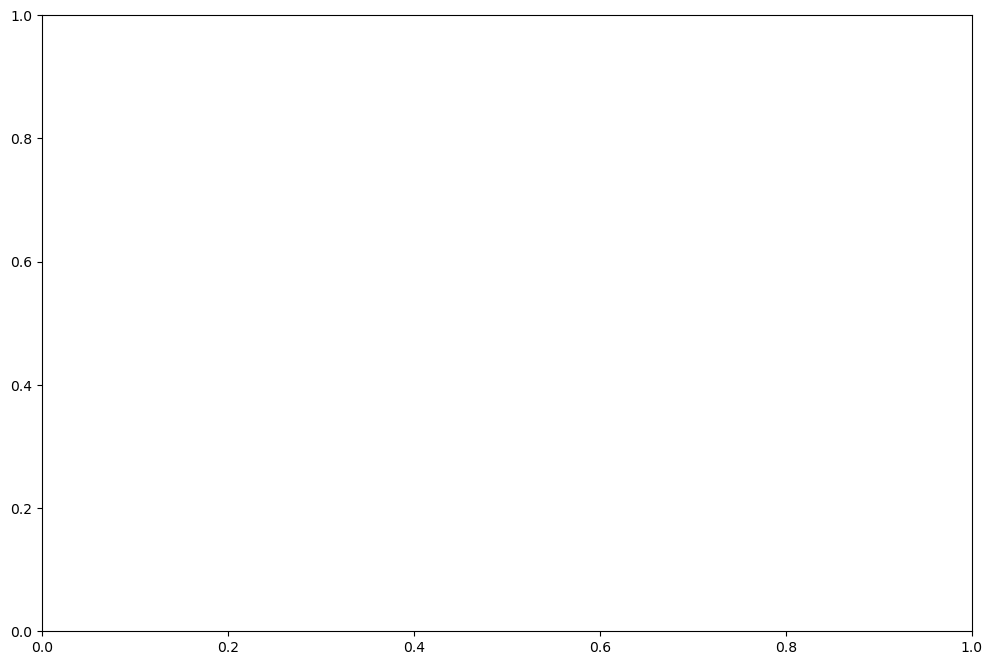

In [16]:
resolutions = {layer: len(curve) for layer, curve in all_spectra_18.items()}

def interpolate_spectrum_to_common_grid(curve, resolution, ref_res, num_points=1000):
    """
    Интерполирует спектр на общую сетку частот.
    
    Параметры:
        curve: array - радиальный спектр
        resolution: int - разрешение слоя
        ref_res: int - разрешение эталонного слоя
        num_points: int - количество точек в целевой сетке
    
    Возвращает:
        r_common: array - общая сетка частот
        curve_interp: array - интерполированный спектр
    """
    # Нормализация
    curve_norm = curve / np.sum(curve)
    
    # Исходные частоты
    L = len(curve)
    r_orig = np.arange(L) / (L - 1)
    
    # Масштабирование
    scale = resolution / ref_res
    r_mapped = r_orig * scale
    
    # Целевая сетка (только до максимальной доступной частоты)
    max_freq = min(1.0, scale)  # не может быть больше 1
    r_common = np.linspace(0, max_freq, num_points)
    
    # Интерполяция
    interp_func = interp1d(r_mapped, curve_norm, kind='linear', 
                           bounds_error=False, fill_value=0.0)
    curve_interp = interp_func(r_common)
    
    return r_common, curve_interp


def prepare_spectra_for_plotting(all_spectra, resolutions, ref_layer='layer1', num_points=1000):
    """
    Подготавливает все спектры для визуализации: интерполирует на общую сетку.
    
    Возвращает:
        spectra_interp: dict {layer: {'r': array, 'curves': list_of_arrays, 'mean': array, 'std': array}}
    """
    ref_res = resolutions[ref_layer]
    spectra_interp = {}
    
    for layer, curves in all_spectra.items():
        resolution = resolutions[layer]
        
        # Интерполируем все кривые
        interp_curves = []
        r_common = None
        
        for curve in curves:
            r, curve_interp = interpolate_spectrum_to_common_grid(
                curve, resolution, ref_res, num_points
            )
            if r_common is None:
                r_common = r
            interp_curves.append(curve_interp)
        
        # Преобразуем в массив для удобства
        interp_curves = np.array(interp_curves)
        
        spectra_interp[layer] = {
            'r': r_common,
            'curves': interp_curves,
            'mean': np.mean(interp_curves, axis=0),
            'std': np.std(interp_curves, axis=0),
            'n_samples': len(interp_curves)
        }
    
    return spectra_interp


# ============================================================
# 2. Различные типы визуализации
# ============================================================

def plot_all_layers_comparison(spectra_interp, layers=None, title=None, figsize=(12, 8)):
    """
    Сравнивает средние спектры всех слоёв на одном графике.
    
    Параметры:
        spectra_interp: dict от prepare_spectra_for_plotting
        layers: list - список слоёв для отображения (по умолчанию все)
        title: str - заголовок
        figsize: tuple - размер фигуры
    """
    if layers is None:
        layers = list(spectra_interp.keys())
    
    # Сортируем слои по порядку (layer1, layer2, ...)
    layers = sorted(layers)
    
    plt.figure(figsize=figsize)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(layers)))
    
    for i, layer in enumerate(layers):
        data = spectra_interp[layer]
        r = data['r']
        std = data['std']
        mean = data['mean'] / max(data['mean'])
        L = data["n_samples"]
        x = np.arange(L) / (L - 1)  # normalized frequency radius
        scale = resolutions[layer] / resolutions["layer1"]
        x_mapped = x * scale

        plt.plot(x_mapped, mean, color=colors[i], linewidth=2, label=f"{layer} (n={data['n_samples']})")
        plt.fill_between(r, mean - std, mean + std, 
                     color='blue', alpha=0.3, label='±1 std')

        plt.plot(x_mapped, curve, label=layer, color=f"C{i}", linewidth=2)

    
    if title is None:
        title = "Mean Spectra Comparison Across Layers"
    plt.title(title)
    plt.xlabel("Normalized frequency (Layer1 scale)")
    plt.ylabel("Normalized spectral energy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_all_layers_comparison(prepare_spectra_for_plotting(all_spectra_34, resolutions))

In [15]:
resolutions = {name:int(40/(i+1)) for i, name in enumerate(["layer1", "layer2", "layer3", "layer4"])}
metrics_summary, all_metrics, r_common = compute_metrics_with_uncertainty(spectra, resolutions)

NameError: name 'spectra' is not defined

In [32]:
pd.DataFrame(metrics_summary).T

,centroid,low_frac,high_frac,n_samples
layer1,"(0.18049165700535993, 0.010087019964337014)","(17.023962596337086, 0.6134891422984367)","(1.9759277780312925, 0.23409804895426414)",100
layer2,"(0.12289976318474306, 0.0038472133483931116)","(20.92632888951198, 0.3216534482634237)","(0.0, 0.0)",100
layer3,"(0.08816761057103234, 0.0019973483180048867)","(33.65172966675377, 0.2532780271226271)","(0.0, 0.0)",100
layer4,"(0.06970251279042432, 0.0006308194504882062)","(61.712921685085014, 0.06534437947302281)","(0.0, 0.0)",100


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# 1. Базовые функции для обработки спектров
# ============================================================

def interpolate_spectrum_to_common_grid(curve, resolution, ref_res, num_points=1000):
    """
    Интерполирует спектр на общую сетку частот.
    
    Параметры:
        curve: array - радиальный спектр
        resolution: int - разрешение слоя
        ref_res: int - разрешение эталонного слоя
        num_points: int - количество точек в целевой сетке
    
    Возвращает:
        r_common: array - общая сетка частот
        curve_interp: array - интерполированный спектр
    """
    # Нормализация
    curve_norm = curve / np.sum(curve)
    
    # Исходные частоты
    L = len(curve)
    r_orig = np.arange(L) / (L - 1)
    
    # Масштабирование
    scale = resolution / ref_res
    r_mapped = r_orig * scale
    
    # Целевая сетка (только до максимальной доступной частоты)
    max_freq = min(1.0, scale)  # не может быть больше 1
    r_common = np.linspace(0, max_freq, num_points)
    
    # Интерполяция
    interp_func = interp1d(r_mapped, curve_norm, kind='linear', 
                           bounds_error=False, fill_value=0.0)
    curve_interp = interp_func(r_common)
    
    return r_common, curve_interp


def prepare_spectra_for_plotting(all_spectra, resolutions, ref_layer='layer1', num_points=1000):
    """
    Подготавливает все спектры для визуализации: интерполирует на общую сетку.
    
    Возвращает:
        spectra_interp: dict {layer: {'r': array, 'curves': list_of_arrays, 'mean': array, 'std': array}}
    """
    ref_res = resolutions[ref_layer]
    spectra_interp = {}
    
    for layer, curves in all_spectra.items():
        resolution = resolutions[layer]
        
        # Интерполируем все кривые
        interp_curves = []
        r_common = None
        
        for curve in curves:
            r, curve_interp = interpolate_spectrum_to_common_grid(
                curve, resolution, ref_res, num_points
            )
            if r_common is None:
                r_common = r
            interp_curves.append(curve_interp)
        
        # Преобразуем в массив для удобства
        interp_curves = np.array(interp_curves)
        
        spectra_interp[layer] = {
            'r': r_common,
            'curves': interp_curves,
            'mean': np.mean(interp_curves, axis=0),
            'std': np.std(interp_curves, axis=0),
            'n_samples': len(interp_curves)
        }
    
    return spectra_interp


# ============================================================
# 2. Различные типы визуализации
# ============================================================

def plot_all_individual_curves(spectra_interp, layer, title=None, alpha=0.3, figsize=(10, 6)):
    """
    Визуализирует все индивидуальные кривые для одного слоя.
    
    Параметры:
        spectra_interp: dict от prepare_spectra_for_plotting
        layer: str - имя слоя
        title: str - заголовок (опционально)
        alpha: float - прозрачность кривых
        figsize: tuple - размер фигуры
    """
    data = spectra_interp[layer]
    r = data['r']
    curves = data['curves']
    mean = data['mean']
    
    plt.figure(figsize=figsize)
    
    # Все индивидуальные кривые
    for i, curve in enumerate(curves):
        plt.plot(r, curve, color='gray', alpha=alpha, linewidth=0.5, 
                 label='Individual' if i == 0 else '')
    
    # Средняя кривая
    plt.plot(r, mean, color='red', linewidth=2, label='Mean')
    
    # Настройки
    if title is None:
        title = f"{layer}: All Individual Spectra (n={len(curves)})"
    plt.title(title)
    plt.xlabel("Normalized frequency (Layer1 scale)")
    plt.ylabel("Normalized spectral energy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_mean_with_std_band(spectra_interp, layer, title=None, figsize=(10, 6)):
    """
    Визуализирует среднюю кривую с доверительным интервалом (±1 std).
    
    Параметры:
        spectra_interp: dict от prepare_spectra_for_plotting
        layer: str - имя слоя
        title: str - заголовок (опционально)
        figsize: tuple - размер фигуры
    """
    data = spectra_interp[layer]
    r = data['r']
    mean = data['mean']
    std = data['std']
    
    plt.figure(figsize=figsize)
    
    # Доверительный интервал (заливка)
    plt.fill_between(r, mean - std, mean + std, 
                     color='blue', alpha=0.3, label='±1 std')
    
    # Средняя кривая
    plt.plot(r, mean, color='blue', linewidth=2, label='Mean')
    
    # Настройки
    if title is None:
        title = f"{layer}: Mean Spectrum with ±1σ Band (n={data['n_samples']})"
    plt.title(title)
    plt.xlabel("Normalized frequency (Layer1 scale)")
    plt.ylabel("Normalized spectral energy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_all_layers_comparison(spectra_interp, layers=None, title=None, figsize=(12, 8)):
    """
    Сравнивает средние спектры всех слоёв на одном графике.
    
    Параметры:
        spectra_interp: dict от prepare_spectra_for_plotting
        layers: list - список слоёв для отображения (по умолчанию все)
        title: str - заголовок
        figsize: tuple - размер фигуры
    """
    if layers is None:
        layers = list(spectra_interp.keys())
    
    # Сортируем слои по порядку (layer1, layer2, ...)
    layers = sorted(layers)
    
    plt.figure(figsize=figsize)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(layers)))
    
    # for i, layer in enumerate(layers):
    #     data = spectra_interp[layer]
    #     r = data['r']
    #     mean = data['mean']
    #     plt.plot(r, mean, color=colors[i], linewidth=2, label=f"{layer} (n={data['n_samples']})")
        
    for i, (layer, curve) in enumerate(spectra_interp.items()):
        curve = curve / max(curve)  # normalize energy
        L = len(curve)
        x = np.arange(L) / (L - 1)  # normalized frequency radius
        scale = resolutions[layer] / ref_res  # map to Layer1 frequency scale
        x_mapped = x * scale
        plt.plot(x_mapped, curve, label=layer, color=f"C{i}", linewidth=2)
    
    if title is None:
        title = "Mean Spectra Comparison Across Layers"
    plt.title(title)
    plt.xlabel("Normalized frequency (Layer1 scale)")
    plt.ylabel("Normalized spectral energy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_all_layers_with_error_bands(spectra_interp, layers=None, title=None, figsize=(12, 8)):
    """
    Сравнивает средние спектры всех слоёв с доверительными интервалами.
    """
    if layers is None:
        layers = list(spectra_interp.keys())
    layers = sorted(layers)
    
    plt.figure(figsize=figsize)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(layers)))
    
    for i, layer in enumerate(layers):
        data = spectra_interp[layer]
        r = data['r']
        mean = data['mean']
        std = data['std']
        
        # Заливка доверительного интервала
        plt.fill_between(r, mean - std, mean + std, 
                         color=colors[i], alpha=0.2)
        # Средняя кривая
        plt.plot(r, mean, color=colors[i], linewidth=2, label=f"{layer}")
    
    if title is None:
        title = "Mean Spectra with ±1σ Bands Across Layers"
    plt.title(title)
    plt.xlabel("Normalized frequency (Layer1 scale)")
    plt.ylabel("Normalized spectral energy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_subplots_by_layer(spectra_interp, layers=None, figsize=(15, 10)):
    """
    Создаёт subplot для каждого слоя, показывая индивидуальные кривые и среднюю.
    
    Параметры:
        spectra_interp: dict от prepare_spectra_for_plotting
        layers: list - список слоёв
        figsize: tuple - размер фигуры
    """
    if layers is None:
        layers = list(spectra_interp.keys())
    layers = sorted(layers)
    
    n_layers = len(layers)
    n_cols = 2
    n_rows = (n_layers + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for i, layer in enumerate(layers):
        ax = axes[i]
        data = spectra_interp[layer]
        r = data['r']
        curves = data['curves']
        mean = data['mean']
        std = data['std']
        
        # Индивидуальные кривые
        for curve in curves:
            ax.plot(r, curve, color='gray', alpha=0.3, linewidth=0.5)
        
        # Средняя с доверительным интервалом
        ax.fill_between(r, mean - std, mean + std, color='red', alpha=0.3)
        ax.plot(r, mean, color='red', linewidth=2)
        
        ax.set_title(f"{layer} (n={data['n_samples']})")
        ax.set_xlabel("Normalized frequency")
        ax.set_ylabel("Normalized energy")
        ax.grid(True, alpha=0.3)
    
    # Скрываем неиспользуемые subplot'ы
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# 3. Визуализация метрик (центроид, low_frac) с погрешностью
# ============================================================

def plot_metric_with_error_bars(metrics_summary, metric_name='centroid', 
                                title=None, figsize=(10, 6)):
    """
    Строит график метрики с error bars для всех слоёв.
    
    Параметры:
        metrics_summary: dict от compute_metrics_with_uncertainty
        metric_name: 'centroid', 'low_frac', или 'high_frac'
        title: str - заголовок
        figsize: tuple - размер фигуры
    """
    # Сортируем слои
    layers = sorted(metrics_summary.keys())
    
    means = []
    stds = []
    
    for layer in layers:
        mean, std = metrics_summary[layer][metric_name]
        means.append(mean)
        stds.append(std)
    
    plt.figure(figsize=figsize)
    
    x = np.arange(len(layers))
    plt.errorbar(x, means, yerr=stds, fmt='o-', capsize=5, capthick=2,
                 markersize=8, linewidth=2, color='blue', ecolor='gray', elinewidth=1.5)
    
    plt.xticks(x, layers)
    plt.xlabel("Layer")
    
    if metric_name == 'centroid':
        plt.ylabel("Spectral Centroid")
        if title is None:
            title = "Spectral Centroid Evolution with Error Bars"
    elif metric_name == 'low_frac':
        plt.ylabel("Low Frequency Fraction (<0.2)")
        if title is None:
            title = "Low Frequency Fraction Evolution with Error Bars"
    else:
        plt.ylabel("High Frequency Fraction (>0.5)")
        if title is None:
            title = "High Frequency Fraction Evolution with Error Bars"
    
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    # Добавляем подписи значений
    for i, (mean, std) in enumerate(zip(means, stds)):
        plt.annotate(f"{mean:.3f}", (x[i], mean), 
                     textcoords="offset points", xytext=(0, 10), 
                     ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. Полный пайплайн визуализации
# ============================================================

def visualize_all(spectra_interp, metrics_summary, model_name="Model"):
    """
    Создаёт полный набор визуализаций для одной модели.
    
    Параметры:
        spectra_interp: dict от prepare_spectra_for_plotting
        metrics_summary: dict от compute_metrics_with_uncertainty
        model_name: str - имя модели для заголовков
    """
    print(f"\n{'='*60}")
    print(f"Visualizing {model_name}")
    print(f"{'='*60}")
    
    # 1. Все слои на одном графике (средние)
    plot_all_layers_comparison(spectra_interp, 
                                title=f"{model_name}: Mean Spectra Across Layers")
    
    # 2. Все слои с доверительными интервалами
    plot_all_layers_with_error_bands(spectra_interp,
                                       title=f"{model_name}: Mean Spectra with ±1σ Bands")
    
    # 3. Subplot для каждого слоя (индивидуальные кривые)
    plot_subplots_by_layer(spectra_interp)
    
    # 4. Графики метрик с погрешностью
    plot_metric_with_error_bars(metrics_summary, 'centroid',
                                 title=f"{model_name}: Spectral Centroid with Error Bars")
    plot_metric_with_error_bars(metrics_summary, 'low_frac',
                                 title=f"{model_name}: Low Frequency Fraction with Error Bars")
    plot_metric_with_error_bars(metrics_summary, 'high_frac',
                                 title=f"{model_name}: High Frequency Fraction with Error Bars")
    
    # 5. Детальный график для последнего слоя (индивидуальные кривые)
    last_layer = sorted(spectra_interp.keys())[-1]
    plot_all_individual_curves(spectra_interp, last_layer,
                                title=f"{model_name}: {last_layer} - All Individual Spectra")
    plot_mean_with_std_band(spectra_interp, last_layer,
                            title=f"{model_name}: {last_layer} - Mean with ±1σ Band")


# ============================================================
# 5. Функция для сравнения нескольких моделей
# ============================================================

def compare_models_across_layers(all_models_metrics, metric_name='centroid', 
                                  title=None, figsize=(12, 6)):
    """
    Сравнивает метрики нескольких моделей на одном графике.
    
    Параметры:
        all_models_metrics: dict {model_name: metrics_summary}
        metric_name: 'centroid', 'low_frac', или 'high_frac'
        title: str - заголовок
        figsize: tuple - размер фигуры
    """
    plt.figure(figsize=figsize)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_models_metrics)))
    
    for (model_name, metrics_summary), color in zip(all_models_metrics.items(), colors):
        layers = sorted(metrics_summary.keys())
        means = [metrics_summary[layer][metric_name][0] for layer in layers]
        stds = [metrics_summary[layer][metric_name][1] for layer in layers]
        
        x = np.arange(len(layers))
        plt.errorbar(x, means, yerr=stds, fmt='o-', capsize=5, capthick=2,
                     markersize=6, linewidth=2, color=color, 
                     label=f"{model_name}", ecolor=color, alpha=0.7)
    
    plt.xticks(x, layers)
    plt.xlabel("Layer")
    
    if metric_name == 'centroid':
        plt.ylabel("Spectral Centroid")
    elif metric_name == 'low_frac':
        plt.ylabel("Low Frequency Fraction (<0.2)")
    else:
        plt.ylabel("High Frequency Fraction (>0.5)")
    
    if title is None:
        title = f"Comparison of {metric_name.replace('_', ' ').title()} Across Models"
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. Пример использования
# ============================================================

def example_full_visualization():
    """
    Полный пример визуализации на синтетических данных.
    """
    # Создаём синтетические данные
    np.random.seed(42)
    
    resolutions = {'layer1': 56, 'layer2': 28, 'layer3': 14, 'layer4': 7}
    
    # all_spectra = {}
    
    # for layer, res in resolutions.items():
    #     n_points = int(res / np.sqrt(2)) + 1
    #     curves = []
        
    #     for _ in range(20):  # 20 батчей
    #         r = np.linspace(0, 1, n_points)
    #         # Разная скорость затухания для разных слоёв
    #         decay = 3.0 if layer == 'layer1' else 5.0 if layer == 'layer2' else 8.0
    #         curve = np.exp(-r * decay) + np.random.normal(0, 0.01, n_points)
    #         curve = np.maximum(curve, 0)
    #         curves.append(curve)
        
    #     all_spectra[layer] = curves
    all_spectra = {key:[value, value] for key,value in dict(spectra_18).items()}
        
    # Подготавливаем данные для визуализации
    spectra_interp = prepare_spectra_for_plotting(all_spectra, resolutions, ref_layer='layer1')
    
    # Вычисляем метрики
    metrics_summary, _, __ = compute_metrics_with_uncertainty(all_spectra, resolutions)
    
    # Визуализируем
    visualize_all(spectra_interp, metrics_summary, model_name="ResNet18")
    
    return spectra_interp, metrics_summary


if __name__ == "__main__":
    # Запускаем пример
    spectra_interp, metrics_summary = example_full_visualization()


Visualizing ResNet18


TypeError: unsupported operand type(s) for /: 'dict' and 'str'

<Figure size 1200x800 with 0 Axes>

## Визуализация между слоями

In [121]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, 20, NUM_WORKERS)
base_model = resnet18(weights=ResNet18_Weights.DEFAULT).to(DEVICE)
model = HookedResNet(base_model).to(DEVICE)
spectra_18 = collect_spectra(model, val_loader, DEVICE, 10)